In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import pickle

from src.helper_functions.reconstruct_parameters import reconstruct_gamma, compute_tau

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colours = [(208/255, 28/255, 139/255),
           (241/255, 182/255, 218/255),
           (184/255, 225/255, 134/255),
           (77/255, 172/255, 38/255)]

colours10 = [(166/255, 206/255, 227/255),
             (31/255, 120/255, 180/255),
             (178/255, 223/255, 138/255),
             (51/255, 160/255, 44/255),
             (251/255, 154/255, 153/255),
             (227/255, 26/255, 28/255),
             (253/255, 191/255, 111/255),
             (255/255, 127/255, 0/255),
             (202/255, 178/255, 214/255),
             (106/255, 61/255, 154/255)]

In [3]:
def load_pickled_file(filepath):
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
    return data

base_path = 'simulations/simulation_3/output'

In [5]:
# layer_groups = []

# phi_w_list = []
# phi_z_list = []
# alpha_rho_list = []
# beta_rho_list = []

# ELBO_full_list = []
layer_groups = {}

phi_w_list = {}
phi_z_list = {}
alpha_rho_list = {}
beta_rho_list = {}

ELBO_full_list = {}

missing_idx = []

for i in range(100):
    try:
        ## SIMULATION PARAMETERS
        # layers
        data = np.load(f'{base_path}/layer_groups/layer_groups_{i}.npy')
        # layer_groups.append(data)
        layer_groups[i] = data
    except FileNotFoundError:
        pass
        
    try:
        ## PARAMETERS
        # phi_w
        data = load_pickled_file(f'{base_path}/phi_w/phi_w_{i}.pkl')
        # phi_w_list.append(data)
        phi_w_list[i] = data
    except FileNotFoundError:
        print(f"Missing phi_w {i}")
        missing_idx.append(i)
    try:
        # phi_u
        data = load_pickled_file(f'{base_path}/phi_z/phi_z_{i}.pkl')
        # phi_z_list.append(data)
        phi_z_list[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # alpha_rho
        data = load_pickled_file(f'{base_path}/alpha_rho/alpha_rho_{i}.pkl')
        # alpha_rho_list.append(data)
        alpha_rho_list[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # beta_rho
        data = load_pickled_file(f'{base_path}/beta_rho/beta_rho_{i}.pkl')
        # beta_rho_list.append(data)
        beta_rho_list[i] = data
    except FileNotFoundError:
        pass
    try:
        ## ELBO
        # ELBO_full
        data = load_pickled_file(f'{base_path}/ELBO/ELBO_full_{i}.pkl')
        # ELBO_full_list.append(data)
        ELBO_full_list[i] = data
    except FileNotFoundError:
        pass

In [6]:
global_groups = np.concatenate(
    (np.repeat(0, 150),
     np.repeat(1, 100))
)

num_CAVI = 10
num_sims = 2
num_layers = 10

ARI_w = []
for sim in range(num_sims):
    ARI_sim = []
    for i in range(int(sim * 50), int((sim + 1) * 50)):
        if i not in missing_idx:
            ARI_i = normalized_mutual_info_score(phi_w_list[i].argmax(axis=1), global_groups)
            ARI_sim.append(ARI_i)
    ARI_w.append(np.stack(ARI_sim))

ARI_z = []
for sim in range(num_sims):
    ARI_sim = []
    for l in range(num_layers):
        ARI_sim_layer = []
        for i in range(int(sim * 50), int((sim + 1) * 50)):
            if i not in missing_idx:
                ARI_sim_layer_i = normalized_mutual_info_score(phi_z_list[i].argmax(axis=2)[l], layer_groups[i][l])
                ARI_sim_layer.append(np.array(ARI_sim_layer_i))
        ARI_sim.append(np.stack(ARI_sim_layer))
    ARI_z.append(ARI_sim)
    
ARI_z_across = [np.array(ARI_z[i]).flatten() for i in range(2)]
    

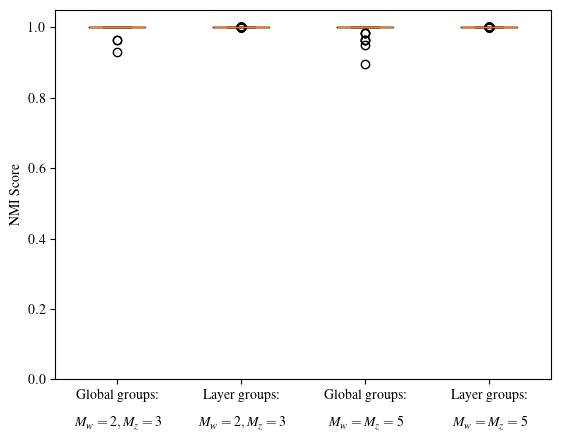

In [9]:
plt.boxplot([ARI_w[0], ARI_z_across[0], ARI_w[1], ARI_z_across[1]]);
plt.ylim(0,1.05);
labels = [r"""Global groups:
          
          $M_w = 2, M_z = 3$""", 
          r"""Layer groups:
          
          $M_w = 2, M_z = 3$""", 
          r"""Global groups:
          
          $M_w = M_z = 5$""", 
          r"""Layer groups:
          
          $M_w = M_z = 5$"""]
plt.xticks(ticks=range(1,5), labels=labels);
plt.ylabel('NMI Score');

# plt.savefig("simulations/simulation_3/plots/NMI_boxplots.pdf", dpi=300, bbox_inches="tight")  # Saves as a high-quality PNG

plt.show()



In [8]:
print("NMI global median (2,3): ",np.median(ARI_w[0]))
print("NMI global std (2,3): ",np.std(ARI_w[0]))
print("NMI global LQ (2,3): ",np.quantile(ARI_w[0], 0.025)) 
print("NMI global UQ (2,3): ",np.quantile(ARI_w[0], 0.975)) 

print("NMI global median (5,5): ",np.median(ARI_w[1]))
print("NMI global std (5,5): ",np.std(ARI_w[1]))
print("NMI global LQ (5,5): ",np.quantile(ARI_w[1], 0.025)) 
print("NMI global UQ (5,5): ",np.quantile(ARI_w[1], 0.975))

NMI global median (2,3):  1.0
NMI global std (2,3):  0.011624881595215597
NMI global LQ (2,3):  0.9655169321364921
NMI global UQ (2,3):  1.0
NMI global median (5,5):  1.0
NMI global std (5,5):  0.01793200639746868
NMI global LQ (5,5):  0.9524061197160796
NMI global UQ (5,5):  1.0
